## 1. Configuração do ambiente

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions  as F
from pyspark.sql.types import DoubleType
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('ENEM Pipeline') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark versão: {spark.version}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/01 16:17:49 WARN Utils: Your hostname, DESKTOP-BLPES8R, resolves to a loopback address: 127.0.1.1; using 172.26.110.18 instead (on interface eth0)
26/06/01 16:17:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 16:17:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark versão: 4.1.2


## 2. Leitura dos dados

Os microdados do ENEM vêm em CSV com separador `;` e encoding `latin-1`. O PySpark lida com isso nativamente.

In [2]:
import os

CSV_PATH = os.path.expanduser('~/enem-pipeline/data/raw/DADOS/MICRODADOS_ENEM_2023.csv')

print(f'Procurando em: {CSV_PATH}')
print(f'Arquivo existe: {os.path.exists(CSV_PATH)}')

df_raw = spark.read \
    .option('header', 'true') \
    .option('sep', ';') \
    .option('encoding', 'ISO-8859-1') \
    .option('inferSchema', 'true') \
    .csv(CSV_PATH)

print(f'Total de linhas: {df_raw.count():,}')
print(f'Total de colunas: {len(df_raw.columns)}')

Procurando em: /home/thiagomota/enem-pipeline/data/raw/DADOS/MICRODADOS_ENEM_2023.csv
Arquivo existe: True


Total de linhas: 3,933,955
Total de colunas: 76


In [ ]:
COLUNAS = [
    'NU_INSCRICAO',
    'NU_ANO',
    'TP_FAIXA_ETARIA',
    'TP_SEXO',
    'TP_ESTADO_CIVIL',
    'TP_COR_RACA',
    'TP_ESCOLA',         
    'TP_ENSINO',
    'IN_TREINEIRO',
    'SG_UF_PROVA',       
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'NU_NOTA_CN',         
    'NU_NOTA_CH',         
    'NU_NOTA_LC',         
    'NU_NOTA_MT',         
    'NU_NOTA_REDACAO',    
    'TP_STATUS_REDACAO',
    'Q001', 'Q002',       # escolaridade pai / mãe
    'Q006',              # renda familiar
    'Q025',              # acesso à internet
]


colunas_existentes = [c for c in COLUNAS if c in df_raw.columns]
df = df_raw.select(colunas_existentes)
df.printSchema()

root
 |-- NU_INSCRICAO: long (nullable = true)
 |-- NU_ANO: integer (nullable = true)
 |-- TP_FAIXA_ETARIA: integer (nullable = true)
 |-- TP_SEXO: string (nullable = true)
 |-- TP_ESTADO_CIVIL: integer (nullable = true)
 |-- TP_COR_RACA: integer (nullable = true)
 |-- TP_ESCOLA: integer (nullable = true)
 |-- TP_ENSINO: integer (nullable = true)
 |-- IN_TREINEIRO: integer (nullable = true)
 |-- SG_UF_PROVA: string (nullable = true)
 |-- TP_PRESENCA_CN: integer (nullable = true)
 |-- TP_PRESENCA_CH: integer (nullable = true)
 |-- TP_PRESENCA_LC: integer (nullable = true)
 |-- TP_PRESENCA_MT: integer (nullable = true)
 |-- NU_NOTA_CN: double (nullable = true)
 |-- NU_NOTA_CH: double (nullable = true)
 |-- NU_NOTA_LC: double (nullable = true)
 |-- NU_NOTA_MT: double (nullable = true)
 |-- NU_NOTA_REDACAO: integer (nullable = true)
 |-- TP_STATUS_REDACAO: integer (nullable = true)
 |-- Q001: string (nullable = true)
 |-- Q002: string (nullable = true)
 |-- Q006: string (nullable = true)
 

## 3. Limpeza dos dados

In [ ]:
df_clean = df.filter(
    (F.col('TP_PRESENCA_CN') == 1) &
    (F.col('TP_PRESENCA_CH') == 1) &
    (F.col('TP_PRESENCA_LC') == 1) &
    (F.col('TP_PRESENCA_MT') == 1) &
    (F.col('NU_NOTA_REDACAO').isNotNull()) &
    (F.col('NU_NOTA_REDACAO') > 0) &
    (F.col('IN_TREINEIRO') == 0)  
)


notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
for col in notas:
    if col in df_clean.columns:
        df_clean = df_clean.withColumn(col, F.col(col).cast(DoubleType()))


df_clean = df_clean.dropna(subset=notas)

total_clean = df_clean.count()
print(f'Registros após limpeza: {total_clean:,}')

Registros após limpeza: 2,095,974


## 4. Análise Exploratória (EDA)

In [ ]:
df_clean.select(notas).describe().show()

26/06/01 16:18:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-----------------+-----------------+-----------------+
|summary|       NU_NOTA_CN|       NU_NOTA_CH|       NU_NOTA_LC|       NU_NOTA_MT|  NU_NOTA_REDACAO|
+-------+-----------------+-----------------+-----------------+-----------------+-----------------+
|  count|          2095974|          2095974|          2095974|          2095974|          2095974|
|   mean|499.3846612124032|529.8524749829899|523.0349499564395|535.9626517790803|647.0105926886498|
| stddev|86.88496784852111|86.68625326833649|73.69823090566814| 131.135670054059|177.2167605851477|
|    min|              0.0|              0.0|              0.0|              0.0|             40.0|
|    max|            868.4|            823.0|            820.8|            958.6|           1000.0|
+-------+-----------------+-----------------+-----------------+-----------------+-----------------+



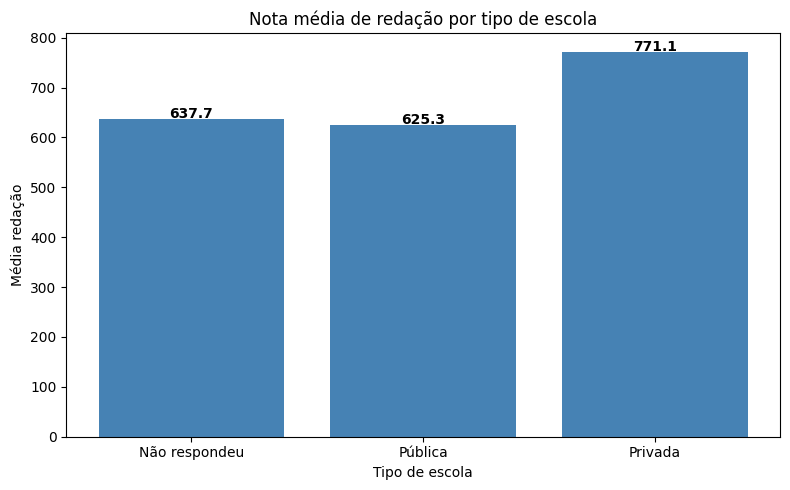

In [6]:
import matplotlib.pyplot as plt

escola_map = {1: 'Não respondeu', 2: 'Pública', 3: 'Privada', 4: 'Exterior'}

media_escola = df_clean.groupBy('TP_ESCOLA') \
    .agg(F.round(F.avg('NU_NOTA_REDACAO'), 1).alias('media_redacao'),
         F.count('*').alias('qtd')) \
    .orderBy('TP_ESCOLA') \
    .toPandas()

media_escola['escola'] = media_escola['TP_ESCOLA'].map(escola_map)

plt.figure(figsize=(8, 5))
plt.bar(media_escola['escola'], media_escola['media_redacao'], color='steelblue')
plt.title('Nota média de redação por tipo de escola')
plt.xlabel('Tipo de escola')
plt.ylabel('Média redação')
for i, v in enumerate(media_escola['media_redacao']):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

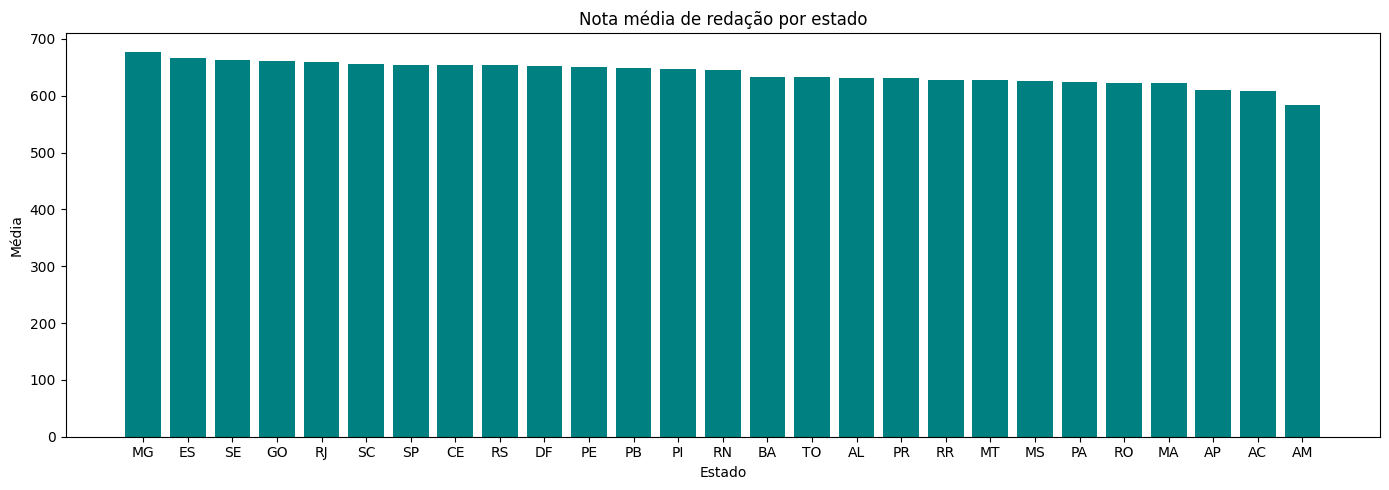

In [7]:
media_uf = df_clean.groupBy('SG_UF_PROVA') \
    .agg(F.round(F.avg('NU_NOTA_REDACAO'), 1).alias('media_redacao')) \
    .orderBy('media_redacao', ascending=False) \
    .toPandas()

plt.figure(figsize=(14, 5))
plt.bar(media_uf['SG_UF_PROVA'], media_uf['media_redacao'], color='teal')
plt.title('Nota média de redação por estado')
plt.xlabel('Estado')
plt.ylabel('Média')
plt.tight_layout()
plt.show()

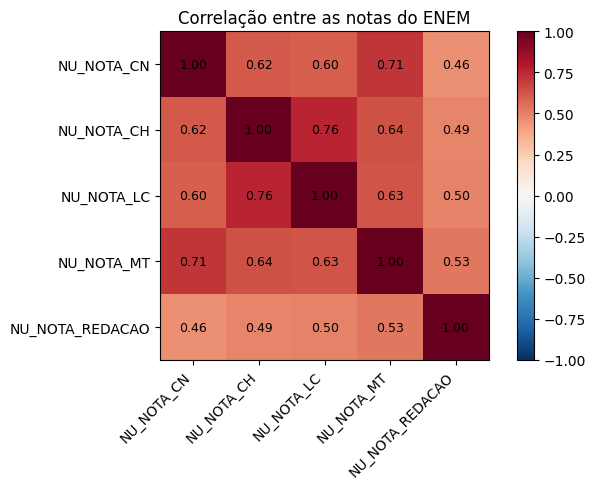

In [8]:
df_sample = df_clean.select(notas).sample(fraction=0.05, seed=42).toPandas()

corr = df_sample.corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.title('Correlação entre as notas do ENEM')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [ ]:
df_feat = df_clean.withColumn(
    'media_objetivas',
    (F.col('NU_NOTA_CN') + F.col('NU_NOTA_CH') +
     F.col('NU_NOTA_LC') + F.col('NU_NOTA_MT')) / 4
)

from pyspark.sql.functions import when, col

df_feat2 = df_feat \
    .withColumn('tem_internet', when(col('Q025') == 'B', 1).otherwise(0)) \
    .withColumn('escolaridade_pai', when(col('Q001') == 'A', 0)
        .when(col('Q001') == 'B', 1).when(col('Q001') == 'C', 2)
        .when(col('Q001') == 'D', 3).when(col('Q001') == 'E', 4)
        .when(col('Q001') == 'F', 5).when(col('Q001') == 'G', 6)
        .when(col('Q001') == 'H', 7).otherwise(0)) \
    .withColumn('escolaridade_mae', when(col('Q002') == 'A', 0)
        .when(col('Q002') == 'B', 1).when(col('Q002') == 'C', 2)
        .when(col('Q002') == 'D', 3).when(col('Q002') == 'E', 4)
        .when(col('Q002') == 'F', 5).when(col('Q002') == 'G', 6)
        .when(col('Q002') == 'H', 7).otherwise(0))



FEATURES = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'media_objetivas']
TARGET = 'NU_NOTA_REDACAO'
FEATURES2 = FEATURES + ['tem_internet', 'escolaridade_pai', 'escolaridade_mae']
FEATURES2 = [f for f in FEATURES2 if f in df_feat2.columns]

df_feat2 = df_feat2.dropna(subset=FEATURES2 + [TARGET])
print(f'Dataset: {df_feat2.count():,} | Features: {FEATURES2}')




if 'TP_ESCOLA' in df_feat.columns:
    FEATURES.append('TP_ESCOLA')
if 'Q006' in df_feat.columns:  
    FEATURES.append('Q006')


df_feat = df_feat.dropna(subset=FEATURES + [TARGET])

print(f'Dataset para modelagem: {df_feat.count():,} registros')
print(f'Features: {FEATURES}')

Dataset: 2,095,974 | Features: ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'media_objetivas', 'tem_internet', 'escolaridade_pai', 'escolaridade_mae']


Dataset para modelagem: 2,095,974 registros
Features: ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'media_objetivas', 'TP_ESCOLA', 'Q006']


## 6. Modelo de Machine Learning

Usamos uma amostra processada pelo Spark e treinamos com sklearn. Estratégia comum em pipelines reais: Spark para ETL em escala, sklearn para modelagem.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np


SAMPLE_SIZE = 100_000
total = df_feat.count()
frac = min(SAMPLE_SIZE / total, 1.0)

df_model = df_feat.select(FEATURES + [TARGET]) \
    .sample(fraction=frac, seed=42) \
    .toPandas()


df_model = df_model.fillna(df_model.median(numeric_only=True))

print(f'Shape do dataset de treino: {df_model.shape}')
df_model.head()

Shape do dataset de treino: (99669, 8)


,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,media_objetivas,TP_ESCOLA,Q006,NU_NOTA_REDACAO
0,424.9,529.4,512.8,398.6,466.425,1,D,540.0
1,457.4,412.6,476.4,355.0,425.350,1,B,780.0
2,525.5,579.3,517.8,618.6,560.300,1,A,420.0
3,506.5,518.2,515.4,428.2,492.075,2,B,400.0
4,505.0,541.1,472.2,617.1,533.850,1,B,860.0


In [ ]:

total = df_feat2.count()
frac = min(100000 / total, 1.0)

df_model2 = df_feat2.select(FEATURES2 + [TARGET]).sample(fraction=frac, seed=42).toPandas()


for col in df_model2.select_dtypes(include='object').columns:
    df_model2[col] = df_model2[col].apply(lambda x: ord(str(x)) - ord('A') + 1 if pd.notna(x) else 0)

df_model2 = df_model2.fillna(df_model2.median(numeric_only=True))

X2 = df_model2[FEATURES2]
y2 = df_model2[TARGET]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelos2 = {
    'Regressao Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

resultados2 = []
for nome, modelo in modelos2.items():
    modelo.fit(X_train2, y_train2)
    pred = modelo.predict(X_test2)
    mae = mean_absolute_error(y_test2, pred)
    r2 = r2_score(y_test2, pred)
    resultados2.append({'Modelo': nome, 'MAE': round(mae, 2), 'R2': round(r2, 4)})
    print(f'{nome:25s} -> MAE: {mae:.2f} | R2: {r2:.4f}')

pd.DataFrame(resultados2)

Regressao Linear          -> MAE: 116.17 | R2: 0.3445
Random Forest             -> MAE: 114.77 | R2: 0.3545
Gradient Boosting         -> MAE: 114.22 | R2: 0.3614
XGBoost                   -> MAE: 114.64 | R2: 0.3562


,Modelo,MAE,R2
0,Regressao Linear,116.17,0.3445
1,Random Forest,114.77,0.3545
2,Gradient Boosting,114.22,0.3614
3,XGBoost,114.64,0.3562


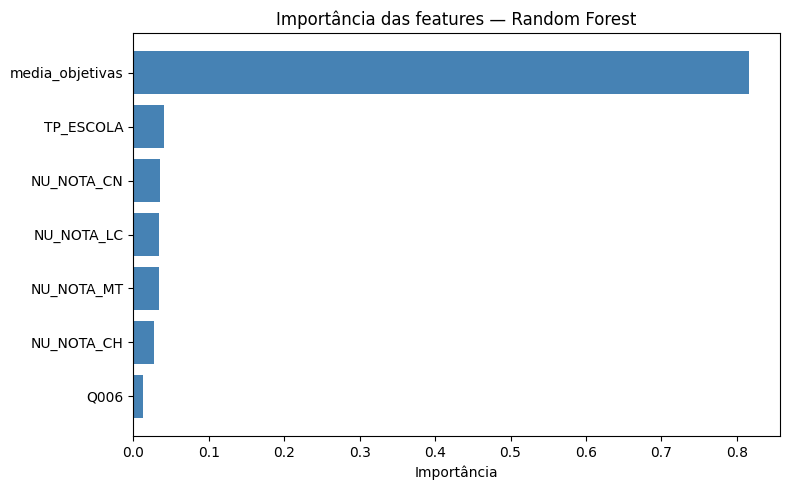

In [20]:
rf = modelos['Random Forest']
importancias = pd.DataFrame({
    'feature': FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importancias['feature'], importancias['importancia'], color='steelblue')
plt.title('Importância das features — Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

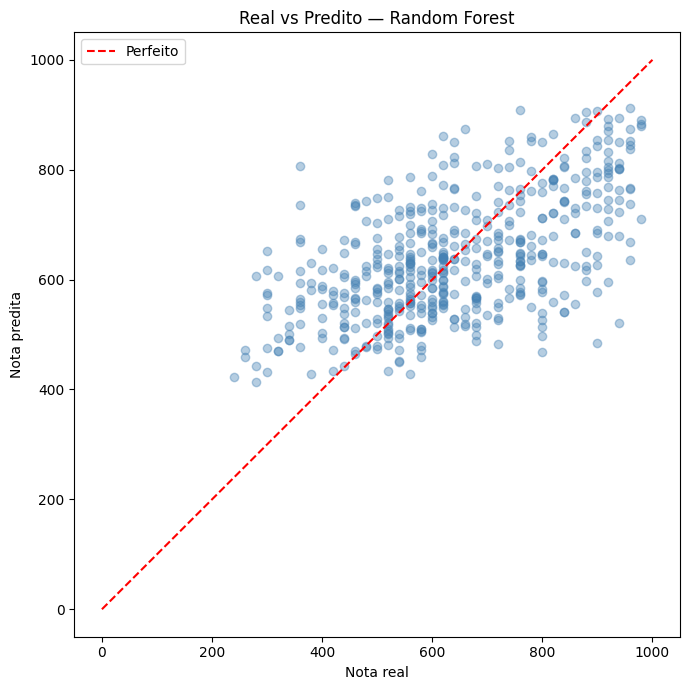

In [21]:
pred_rf = modelos['Random Forest'].predict(X_test)
df_plot = pd.DataFrame({'real': y_test.values[:500], 'predito': pred_rf[:500]})

plt.figure(figsize=(7, 7))
plt.scatter(df_plot['real'], df_plot['predito'], alpha=0.4, color='steelblue')
plt.plot([0, 1000], [0, 1000], color='red', linestyle='--', label='Perfeito')
plt.xlabel('Nota real')
plt.ylabel('Nota predita')
plt.title('Real vs Predito — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Salvar resultados processados

In [ ]:

df_feat.write \
    .mode('overwrite') \
    .parquet('data/processed/enem_clean.parquet')

print('Dados salvos em data/processed/enem_clean.parquet')

Dados salvos em data/processed/enem_clean.parquet


In [ ]:
import pickle, os
os.makedirs(os.path.expanduser('~/enem-pipeline/src'), exist_ok=True)


with open(os.path.expanduser('~/enem-pipeline/src/modelo_rf.pkl'), 'wb') as f:
    pickle.dump(modelos['Random Forest'], f)
print('Modelo salvo')

Modelo salvo


## 8. Encerrando sessão spark

In [26]:
spark.stop()
print('Sessão Spark encerrada.')

Sessão Spark encerrada.
